# Adult Income Logistic Regression Classifier

This notebook builds and evaluates a **Logistic Regression** classifier to predict whether a person's income is `>50K` or `<=50K`.

## Experiment Goals

- Build a clear and reproducible logistic regression classifier that can be compared with the previous kNN and SVM notebooks.
- Use the same prepared data, selected features, split strategy, preprocessing, and final holdout protocol used for kNN and SVM.
- Separate the labeled data into development data, a final holdout split, and the competition test set.
- Use **5-fold stratified cross-validation** to choose the logistic regression regularization hyperparameter `C`.
- Measure final performance on a **holdout** split that is not used for model selection.
- Save the selected hyperparameter, complete grid-search results, final metrics, comparison with kNN and SVM, and submission file.

## How To Read This Notebook

The workflow follows the same supervised machine learning process used in the kNN and SVM notebooks:

1. **Labeled training data**: examples with input features `X` and known target labels `income`.
2. **Holdout split**: part of the training data is reserved for final evaluation.
3. **Cross-validation**: the remaining development data is split into 5 folds to compare `C` values.
4. **Model selection**: the model with the highest mean cross-validation accuracy is selected, with a documented tie-break rule.
5. **Final evaluation**: accuracy, error rate, precision, recall/sensitivity, specificity, F1-score, ROC AUC, and the confusion matrix are computed on the holdout split exactly once.
6. **Comparison with kNN and SVM**: all classifiers are compared using the same holdout protocol.
7. **Final training**: after model selection and holdout evaluation, the selected logistic regression pipeline is fit again on the full labeled training set and used to generate the submission.

## Key Difference From kNN and SVM

Logistic regression learns a linear model in the transformed feature space, like a linear SVM, but its output is a **class probability**. In this notebook, the model estimates `P(income = >50K)` and then applies a decision threshold of `0.5`:

- probability below `0.5`: predict `<=50K`;
- probability at least `0.5`: predict `>50K`.

The main hyperparameter is `C`, the inverse of regularization strength:

- smaller `C`: stronger regularization and simpler coefficients;
- larger `C`: weaker regularization and more flexible coefficients.

The final test set is never used to choose `C`, compare candidate models, or report local performance.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)

warnings.filterwarnings(
    "ignore",
    message="'penalty' was deprecated.*",
    category=FutureWarning,
    module="sklearn.linear_model._logistic",
)


In [2]:
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "data" / "prepared" / "adult_income").exists():
            return candidate
    raise FileNotFoundError("Could not find data/prepared/adult_income from the current working directory.")


PROJECT_ROOT = resolve_project_root()
PREPARED_DIR = PROJECT_ROOT / "data" / "prepared" / "adult_income"
TRAIN_PREPARED_PATH = PREPARED_DIR / "train_prepared.csv"
TEST_PREPARED_PATH = PREPARED_DIR / "test_prepared.csv"
SAMPLE_SUBMISSION_PATH = PREPARED_DIR / "sample_submission.csv"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

train_prepared = pd.read_csv(TRAIN_PREPARED_PATH)
test_prepared = pd.read_csv(TEST_PREPARED_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

ID_COL = "Id"
TARGET_COL = "income"
NEGATIVE_LABEL = "<=50K"
POSITIVE_LABEL = ">50K"

assert ID_COL in train_prepared.columns, "train_prepared.csv must contain Id."
assert TARGET_COL in train_prepared.columns, "train_prepared.csv must contain income."
assert ID_COL in test_prepared.columns, "test_prepared.csv must contain Id."
assert TARGET_COL not in test_prepared.columns, "test_prepared.csv must not contain income."
assert sample_submission.columns.tolist() == [ID_COL, TARGET_COL], "sample_submission.csv must have columns Id and income."
assert len(sample_submission) == len(test_prepared), "sample_submission.csv row count must match test_prepared.csv."
assert set(train_prepared[TARGET_COL].unique()) == {NEGATIVE_LABEL, POSITIVE_LABEL}, "Unexpected training labels found in income."

print(f"Project root: {PROJECT_ROOT}")
print(f"Train prepared shape: {train_prepared.shape}")
print(f"Test prepared shape: {test_prepared.shape}")
print(f"Sample submission shape: {sample_submission.shape}")


Project root: /home/matheuscm/classifier-adults-dataset
Train prepared shape: (32536, 29)
Test prepared shape: (16280, 28)
Sample submission shape: (16280, 2)


## Features and Target Variable

The target variable is `income`, converted into a binary classification target:

- `0`: `<=50K`
- `1`: `>50K`

To keep the comparison with kNN and SVM fair, this notebook uses the **same compact feature set** selected in the previous classifier notebooks.

The selected numeric features are median-imputed and robust-scaled. The selected categorical features are missing-value-imputed and one-hot encoded. This produces the numeric matrix used by logistic regression to estimate class probabilities.

Important points:

- The `Id` column is not used as a feature because it is only an identifier.
- The competition test set has no `income` column, so it cannot be used for local model evaluation.
- The same feature preprocessing is fit only inside the training folds during cross-validation, because it lives inside the scikit-learn `Pipeline`.
- Logistic regression benefits from scaled numeric variables because regularization acts on the fitted coefficients.


In [3]:
NUMERIC_FEATURES = [
    "age",
    "education.num",
    "hours.per.week",
    "log1p_fnlwgt",
    "log1p_capital_gain",
    "log1p_capital_loss",
]

CATEGORICAL_FEATURES = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

SELECTED_FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_FEATURE_COLUMNS = [
    ID_COL,
    TARGET_COL,
    "fnlwgt",
    "capital.gain",
    "capital.loss",
    "age_band",
    "hours_ge_50",
    "hours_ge_60",
    "hours_ge_80",
    "capital_gain_positive",
    "capital_loss_positive",
    "workclass_missing",
    "occupation_missing",
    "native_country_missing",
    "education_level_group",
    "family_role_combo",
]

missing_train_features = sorted(set(SELECTED_FEATURE_COLUMNS) - set(train_prepared.columns))
missing_test_features = sorted(set(SELECTED_FEATURE_COLUMNS) - set(test_prepared.columns))
assert not missing_train_features, f"Missing selected features in train_prepared.csv: {missing_train_features}"
assert not missing_test_features, f"Missing selected features in test_prepared.csv: {missing_test_features}"

X_train_full = train_prepared[SELECTED_FEATURE_COLUMNS].copy()
X_test_final = test_prepared[SELECTED_FEATURE_COLUMNS].copy()
y_binary = (train_prepared[TARGET_COL] == POSITIVE_LABEL).astype(int)

feature_summary_df = pd.DataFrame(
    {
        "feature": SELECTED_FEATURE_COLUMNS,
        "feature_type": ["numeric"] * len(NUMERIC_FEATURES) + ["categorical"] * len(CATEGORICAL_FEATURES),
    }
)

excluded_feature_summary_df = pd.DataFrame({"excluded_feature": EXCLUDED_FEATURE_COLUMNS})

target_distribution_df = pd.DataFrame(
    {
        "income": train_prepared[TARGET_COL].value_counts().index,
        "count": train_prepared[TARGET_COL].value_counts().values,
        "share": train_prepared[TARGET_COL].value_counts(normalize=True).round(4).values,
    }
)

display(feature_summary_df)
display(excluded_feature_summary_df)
display(target_distribution_df)


,feature,feature_type
0,age,numeric
1,education.num,numeric
2,hours.per.week,numeric
3,log1p_fnlwgt,numeric
4,log1p_capital_gain,numeric
5,log1p_capital_loss,numeric
6,workclass,categorical
7,marital.status,categorical
8,occupation,categorical
9,relationship,categorical


,excluded_feature
0,Id
1,income
2,fnlwgt
3,capital.gain
4,capital.loss
5,age_band
6,hours_ge_50
7,hours_ge_60
8,hours_ge_80
9,capital_gain_positive


,income,count,share
0,<=50K,24697,0.7591
1,>50K,7839,0.2409


## Training, Validation, and Hyperparameter Search

Before fitting the model, the labeled training data is split into two parts:

- **Development set (`X_dev`, `y_dev`)**: 80% of the data, used for cross-validation and hyperparameter selection.
- **Holdout set (`X_holdout`, `y_holdout`)**: 20% of the data, used only once for final evaluation.

The split is stratified, so the class proportions of `<=50K` and `>50K` are preserved in both parts. This matters because the dataset is imbalanced: the majority class is `<=50K`.

The holdout set is not used in `GridSearchCV`, not used to choose `C`, and not used to compare candidate logistic regression models.


In [4]:
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_train_full,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary,
)


def split_summary(split_name, y_values):
    value_counts = y_values.value_counts().sort_index()
    return {
        "split": split_name,
        "rows": len(y_values),
        "negative_count": int(value_counts.get(0, 0)),
        "positive_count": int(value_counts.get(1, 0)),
        "positive_rate": round(float(y_values.mean()), 4),
    }


split_summary_df = pd.DataFrame(
    [
        split_summary("development", y_dev),
        split_summary("holdout", y_holdout),
    ]
)

assert len(X_dev) + len(X_holdout) == len(X_train_full), "Development and holdout rows must cover the full labeled set."
assert abs(float(y_dev.mean()) - float(y_binary.mean())) < 0.002, "Development split should preserve target rate."
assert abs(float(y_holdout.mean()) - float(y_binary.mean())) < 0.002, "Holdout split should preserve target rate."

display(split_summary_df)


,split,rows,negative_count,positive_count,positive_rate
0,development,26028,19757,6271,0.2409
1,holdout,6508,4940,1568,0.2409


## Conceptual Note: Beta Coefficients and scikit-learn

In the theoretical formulation studied in class, logistic regression models the probability of the positive class as:

$$
P(Y = 1 \mid X) = \frac{\exp(W)}{1 + \exp(W)},
$$

where

$$
W = \beta_0 + \sum_i \beta_i X_i.
$$

The coefficients $\beta_i$ therefore still exist and are the parameters learned by the model. In the classroom formulation, these coefficients are estimated by **maximum likelihood**.

Unlike ordinary linear regression, logistic regression does not have a simple closed-form solution for the beta coefficients. Because of that, the coefficients are estimated with **iterative numerical methods**. The discipline discusses iterative procedures such as **IRLS** as one way to estimate them.

In the scikit-learn implementation, this numerical optimization is abstracted away. We provide the data, choose a solver, and the solver optimizes the objective function internally. This does not mean that the $\beta_i$ disappeared; it only means that they are computed internally instead of being shown step by step algebraically.

After fitting a scikit-learn logistic regression model, the estimated coefficients can be inspected with:

- `model.coef_`: fitted beta coefficients for the input features;
- `model.intercept_`: fitted intercept term $\beta_0$.

One practical difference from the most basic theoretical presentation is regularization. In scikit-learn, logistic regression can include a regularization penalty, and the hyperparameter `C` controls its strength. Smaller `C` values imply stronger regularization, while larger `C` values imply weaker regularization.


## Cross-Validation

This notebook uses **5-fold StratifiedKFold**. The development set is split into 5 parts. For each `C` value, the pipeline trains on 4 folds and validates on the remaining fold. This repeats 5 times, so each fold is used once as validation.

The table below shows, for each logistic regression `C` value:

- accuracy on fold 1
- accuracy on fold 2
- accuracy on fold 3
- accuracy on fold 4
- accuracy on fold 5
- mean cross-validation accuracy
- standard deviation across folds
- mean training accuracy

## Hyperparameters Tested

- `model__C`: inverse regularization strength.
  - smaller `C`: stronger regularization and simpler coefficients;
  - larger `C`: weaker regularization and more flexible coefficients.

The selection metric is **mean cross-validation accuracy**, matching the kNN and SVM notebooks. If rounded mean CV accuracies tie at 5 decimal places, the explicit tie-break rule chooses the smaller `C`, favoring stronger regularization and a simpler model.

Because the dataset is imbalanced, the final evaluation also reports recall/sensitivity, specificity, F1-score, balanced accuracy, ROC AUC, and the confusion matrix.


### Accuracy by Logistic Regression C
Each row shows one logistic regression `C` value. The fold columns show the accuracy from the 5 stratified folds.

,logreg_C,fold_1_accuracy,fold_2_accuracy,fold_3_accuracy,fold_4_accuracy,fold_5_accuracy,mean_cv_accuracy,std_cv_accuracy,mean_train_accuracy,grid_rank,selected
0,0.001,0.83096,0.82712,0.83807,0.82901,0.82363,0.82976,0.00481,0.82969,9,
1,0.003,0.83999,0.83481,0.84864,0.83612,0.83593,0.83910,0.00508,0.83877,8,
2,0.010,0.84268,0.83519,0.85094,0.83804,0.83919,0.84121,0.00543,0.84253,7,
3,0.030,0.84499,0.83769,0.85305,0.84035,0.84092,0.84340,0.00536,0.84380,6,
4,0.100,0.84403,0.83807,0.85344,0.84111,0.84188,0.84371,0.00523,0.84461,4,
5,0.300,0.84556,0.83788,0.85305,0.84169,0.84111,0.84386,0.00520,0.84527,1,selected
6,1.000,0.84479,0.83826,0.85325,0.84150,0.84073,0.84371,0.00521,0.84521,5,
7,3.000,0.84441,0.83788,0.85382,0.84246,0.84054,0.84382,0.00545,0.84533,2,
8,10.000,0.84479,0.83769,0.85382,0.84207,0.84035,0.84375,0.00554,0.84526,3,


### Folds for the selected C

,fold,logreg_C,accuracy
0,1,0.3,0.84556
1,2,0.3,0.83788
2,3,0.3,0.85305
3,4,0.3,0.84169
4,5,0.3,0.84111


,selection_source,params,mean_cv_accuracy
0,GridSearchCV raw best params,"{""model__C"": 0.3}",0.84386
1,Notebook tie-break selection,"{""model__C"": 0.3}",0.84386


### Final cross-validation result
- Logistic Regression C: `0.3`
- mean CV accuracy: `0.84386`
- fold accuracies: `0.84556, 0.83788, 0.85305, 0.84169, 0.84111`
- tie-break rule: If rounded mean CV accuracies tie, choose the smaller C for stronger regularization.

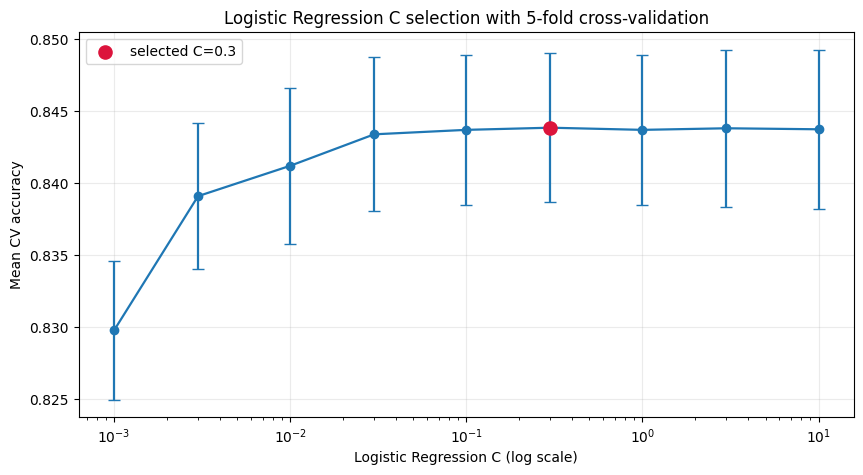

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, NUMERIC_FEATURES),
        ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                random_state=42,
            ),
        ),
    ]
)

C_VALUES = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
N_FOLDS = 5
TIE_BREAK_RULE = "If rounded mean CV accuracies tie, choose the smaller C for stronger regularization."
DECISION_THRESHOLD = 0.5

cv_splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

param_grid = {
    "model__C": C_VALUES,
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_splitter,
    refit=True,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_dev, y_dev)

fold_score_columns = [f"split{fold_idx}_test_score" for fold_idx in range(N_FOLDS)]
fold_accuracy_columns = [f"fold_{fold_idx + 1}_accuracy" for fold_idx in range(N_FOLDS)]

cv_results_df = pd.DataFrame(grid_search.cv_results_)[
    [
        "param_model__C",
        *fold_score_columns,
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score",
    ]
].rename(
    columns={
        "param_model__C": "logreg_C",
        **dict(zip(fold_score_columns, fold_accuracy_columns)),
        "mean_test_score": "mean_cv_accuracy",
        "std_test_score": "std_cv_accuracy",
        "mean_train_score": "mean_train_accuracy",
        "rank_test_score": "grid_rank",
    }
)

cv_results_df["logreg_C"] = cv_results_df["logreg_C"].astype(float)
cv_results_df["mean_cv_accuracy_rounded"] = cv_results_df["mean_cv_accuracy"].round(5)

cv_results_ranked_df = cv_results_df.sort_values(
    by=["mean_cv_accuracy_rounded", "logreg_C"],
    ascending=[False, True],
).reset_index(drop=True)

selected_row = cv_results_ranked_df.iloc[0]
selected_params = {
    "model__C": float(selected_row["logreg_C"]),
}
selected_fold_accuracies = [float(selected_row[column]) for column in fold_accuracy_columns]
selected_fold_accuracy_records = [
    {
        "fold": fold_idx + 1,
        "logreg_C": selected_params["model__C"],
        "accuracy": selected_fold_accuracies[fold_idx],
    }
    for fold_idx in range(N_FOLDS)
]

selected_pipeline = clone(base_pipeline).set_params(**selected_params)
selected_pipeline.fit(X_dev, y_dev)

selection_summary_df = pd.DataFrame(
    [
        {
            "selection_source": "GridSearchCV raw best params",
            "params": json.dumps(grid_search.best_params_, sort_keys=True),
            "mean_cv_accuracy": round(float(grid_search.best_score_), 5),
        },
        {
            "selection_source": "Notebook tie-break selection",
            "params": json.dumps(selected_params, sort_keys=True),
            "mean_cv_accuracy": round(float(selected_row["mean_cv_accuracy"]), 5),
        },
    ]
)

c_cv_display_df = cv_results_df.sort_values("logreg_C").reset_index(drop=True).copy()
c_cv_display_df["selected"] = np.where(
    c_cv_display_df["logreg_C"] == selected_params["model__C"],
    "selected",
    "",
)
c_cv_display_df[fold_accuracy_columns + ["mean_cv_accuracy", "std_cv_accuracy", "mean_train_accuracy"]] = c_cv_display_df[
    fold_accuracy_columns + ["mean_cv_accuracy", "std_cv_accuracy", "mean_train_accuracy"]
].round(5)

selected_fold_accuracy_df = pd.DataFrame(selected_fold_accuracy_records)
selected_fold_accuracy_df["accuracy"] = selected_fold_accuracy_df["accuracy"].round(5)

optimal_c_summary = (
    "### Final cross-validation result\n"
    f"- Logistic Regression C: `{selected_params['model__C']}`\n"
    f"- mean CV accuracy: `{float(selected_row['mean_cv_accuracy']):.5f}`\n"
    f"- fold accuracies: `{', '.join(f'{accuracy:.5f}' for accuracy in selected_fold_accuracies)}`\n"
    f"- tie-break rule: {TIE_BREAK_RULE}"
)

display(
    Markdown(
        "### Accuracy by Logistic Regression C\n"
        "Each row shows one logistic regression `C` value. The fold columns show the accuracy from the 5 stratified folds."
    )
)
display(
    c_cv_display_df[
        [
            "logreg_C",
            *fold_accuracy_columns,
            "mean_cv_accuracy",
            "std_cv_accuracy",
            "mean_train_accuracy",
            "grid_rank",
            "selected",
        ]
    ]
)

display(Markdown("### Folds for the selected C"))
display(selected_fold_accuracy_df)
display(selection_summary_df)
display(Markdown(optimal_c_summary))

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    c_cv_display_df["logreg_C"],
    c_cv_display_df["mean_cv_accuracy"],
    yerr=c_cv_display_df["std_cv_accuracy"],
    fmt="o-",
    capsize=4,
    linewidth=1.6,
)
ax.scatter(
    [selected_params["model__C"]],
    [float(selected_row["mean_cv_accuracy"])],
    color="crimson",
    s=90,
    label=f"selected C={selected_params['model__C']}",
    zorder=3,
)
ax.set_xscale("log")
ax.set_title("Logistic Regression C selection with 5-fold cross-validation")
ax.set_xlabel("Logistic Regression C (log scale)")
ax.set_ylabel("Mean CV accuracy")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Holdout Evaluation

After choosing `C` with cross-validation, the selected logistic regression model is evaluated on the holdout split. The holdout split was not used to choose `C`, so it gives a more honest estimate of performance on unseen labeled data.

## Metrics Reported

- **Accuracy (`accuracy`)**: overall proportion of correct predictions.
- **Error rate (`1 - accuracy`)**: overall proportion of incorrect predictions.
- **Balanced accuracy**: average recall across classes, useful when classes are imbalanced.
- **Precision for class `>50K`**: among samples predicted as `>50K`, how many were truly `>50K`.
- **Recall / sensitivity for class `>50K`**: among truly `>50K` samples, how many the model found.
- **Specificity for class `<=50K`**: among truly `<=50K` samples, how many the model kept as `<=50K`.
- **F1-score for class `>50K`**: harmonic mean of precision and recall.
- **ROC AUC**: how well the model ranks positive samples above negative samples using predicted probabilities.

Because the positive class is the minority class, accuracy alone can hide important mistakes. The confusion matrix, recall/sensitivity, specificity, and F1-score are essential for interpreting performance.


,metric,value
0,accuracy,0.85049
1,error_rate,0.14951
2,balanced_accuracy,0.76396
3,precision_positive,0.73297
4,recall_positive,0.59694
5,sensitivity,0.59694
6,specificity,0.93097
7,f1_positive,0.65800
8,roc_auc,0.89756


,pred_<=50K,pred_>50K
actual_<=50K,4599,341
actual_>50K,632,936


,term,count,meaning
0,true_negatives,4599,<=50K predicted as <=50K
1,false_positives,341,<=50K incorrectly predicted as >50K
2,false_negatives,632,>50K incorrectly predicted as <=50K
3,true_positives,936,>50K predicted as >50K


,precision,recall,f1-score,support
<=50K,0.879182,0.930972,0.904336,4940.000000
>50K,0.732968,0.596939,0.657996,1568.000000
accuracy,0.850492,0.850492,0.850492,0.850492
macro avg,0.806075,0.763955,0.781166,6508.000000
weighted avg,0.843954,0.850492,0.844984,6508.000000


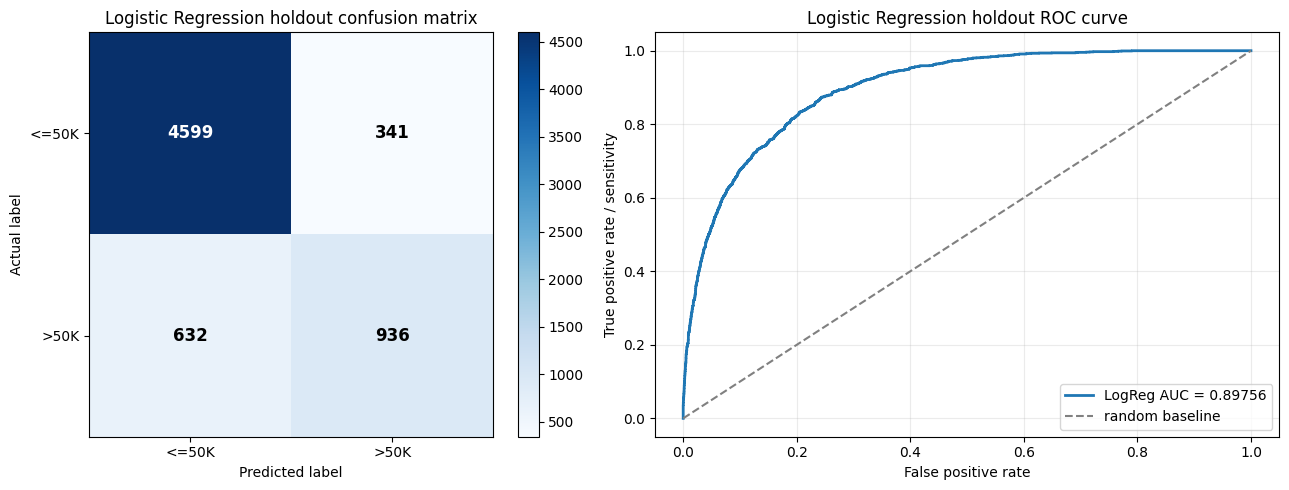

In [6]:
holdout_proba = selected_pipeline.predict_proba(X_holdout)[:, 1]
holdout_pred = (holdout_proba >= DECISION_THRESHOLD).astype(int)
holdout_accuracy = float(accuracy_score(y_holdout, holdout_pred))

tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_pred, labels=[0, 1]).ravel()
sensitivity = float(tp / (tp + fn)) if (tp + fn) else 0.0
specificity = float(tn / (tn + fp)) if (tn + fp) else 0.0

holdout_metrics = {
    "accuracy": holdout_accuracy,
    "error_rate": 1 - holdout_accuracy,
    "balanced_accuracy": float(balanced_accuracy_score(y_holdout, holdout_pred)),
    "precision_positive": float(precision_score(y_holdout, holdout_pred, zero_division=0)),
    "recall_positive": float(recall_score(y_holdout, holdout_pred, zero_division=0)),
    "sensitivity": sensitivity,
    "specificity": specificity,
    "f1_positive": float(f1_score(y_holdout, holdout_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_holdout, holdout_proba)),
}

holdout_metrics_df = pd.DataFrame(
    [
        {"metric": metric_name, "value": round(metric_value, 5)}
        for metric_name, metric_value in holdout_metrics.items()
    ]
)

confusion_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=[f"actual_{NEGATIVE_LABEL}", f"actual_{POSITIVE_LABEL}"],
    columns=[f"pred_{NEGATIVE_LABEL}", f"pred_{POSITIVE_LABEL}"],
)

confusion_terms_df = pd.DataFrame(
    [
        {"term": "true_negatives", "count": int(tn), "meaning": "<=50K predicted as <=50K"},
        {"term": "false_positives", "count": int(fp), "meaning": "<=50K incorrectly predicted as >50K"},
        {"term": "false_negatives", "count": int(fn), "meaning": ">50K incorrectly predicted as <=50K"},
        {"term": "true_positives", "count": int(tp), "meaning": ">50K predicted as >50K"},
    ]
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_holdout,
        holdout_pred,
        target_names=[NEGATIVE_LABEL, POSITIVE_LABEL],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(holdout_metrics_df)
display(confusion_df)
display(confusion_terms_df)
display(classification_report_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(confusion_df.values, cmap="Blues")
axes[0].set_title("Logistic Regression holdout confusion matrix")
axes[0].set_xticks([0, 1], [NEGATIVE_LABEL, POSITIVE_LABEL])
axes[0].set_yticks([0, 1], [NEGATIVE_LABEL, POSITIVE_LABEL])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("Actual label")
for row_idx in range(2):
    for col_idx in range(2):
        axes[0].text(
            col_idx,
            row_idx,
            str(confusion_df.values[row_idx, col_idx]),
            ha="center",
            va="center",
            color="white" if confusion_df.values[row_idx, col_idx] > confusion_df.values.max() / 2 else "black",
            fontsize=12,
            weight="bold",
        )
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

fpr, tpr, roc_thresholds = roc_curve(y_holdout, holdout_proba)
axes[1].plot(fpr, tpr, label=f"LogReg AUC = {holdout_metrics['roc_auc']:.5f}", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="random baseline")
axes[1].set_title("Logistic Regression holdout ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate / sensitivity")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Logistic Regression Feature-Space Interpretation

A logistic regression model learns one coefficient per transformed feature. Positive coefficients increase the log-odds of `>50K`; negative coefficients increase the log-odds of `<=50K`.

This is different from kNN and related to SVM:

- kNN stores training examples and predicts from local neighbor votes;
- linear SVM learns a global hyperplane and uses margin scores;
- logistic regression learns global coefficients and converts the linear score into a probability;
- logistic regression's `C` controls regularization, while kNN's `k` controls neighborhood size and SVM's `C` controls margin regularization.

The PCA plot below is only a 2D visualization. The actual logistic regression model is trained on all preprocessed features, not only two PCA axes.


### Largest Logistic Regression coefficients

,direction,feature,coefficient,absolute_coefficient
0,toward >50K,marital.status_Married-civ-spouse,1.34243,1.34243
1,toward >50K,relationship_Wife,1.18719,1.18719
2,toward >50K,marital.status_infrequent_sklearn,1.07747,1.07747
3,toward >50K,education.num,0.85740,0.85740
4,toward >50K,occupation_Exec-managerial,0.84177,0.84177
5,toward >50K,native.country_Germany,0.68660,0.68660
6,toward >50K,occupation_Tech-support,0.65210,0.65210
7,toward >50K,occupation_Protective-serv,0.63535,0.63535
8,toward >50K,workclass_Federal-gov,0.61824,0.61824
9,toward >50K,occupation_Prof-specialty,0.61285,0.61285


### Representative holdout cases near the Logistic Regression threshold

,case,actual,predicted,probability_>50K,distance_to_threshold_abs
0,Correct <=50K,<=50K,<=50K,0.49977,0.00023
1,Correct >50K,>50K,>50K,0.50048,0.00048
2,False positive,<=50K,>50K,0.50004,0.00004
3,False negative,>50K,<=50K,0.49993,0.00007


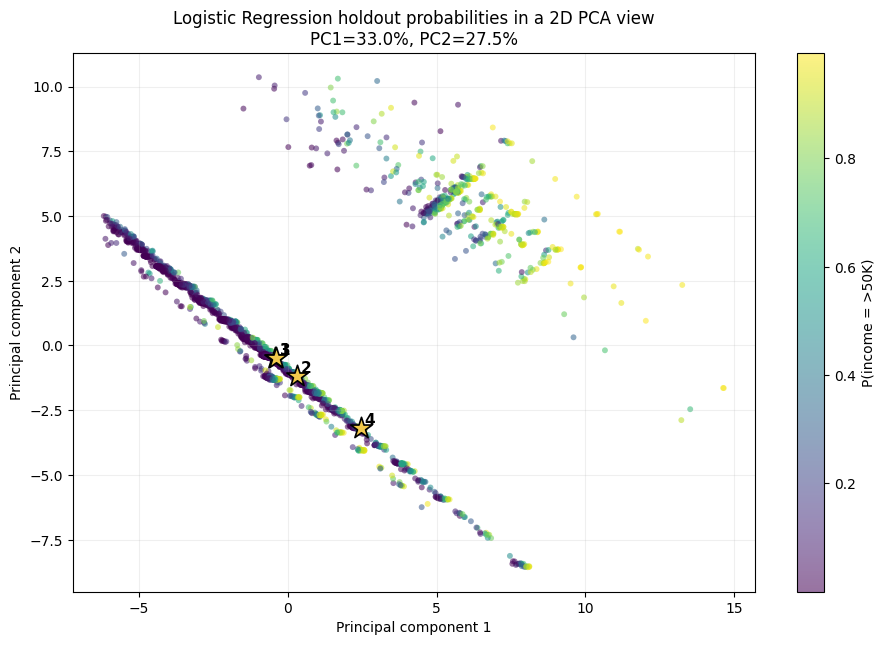

In [7]:
preprocessor = selected_pipeline.named_steps["preprocessor"]
logreg_model = selected_pipeline.named_steps["model"]

X_dev_trans = preprocessor.transform(X_dev)
X_holdout_trans = preprocessor.transform(X_holdout)
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": logreg_model.coef_.ravel(),
    }
)
coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

positive_coef_df = coef_df.sort_values("coefficient", ascending=False).head(12).reset_index(drop=True)
negative_coef_df = coef_df.sort_values("coefficient", ascending=True).head(12).reset_index(drop=True)

coef_display_df = pd.concat(
    [
        positive_coef_df.assign(direction=f"toward {POSITIVE_LABEL}"),
        negative_coef_df.assign(direction=f"toward {NEGATIVE_LABEL}"),
    ],
    ignore_index=True,
)
coef_display_df["coefficient"] = coef_display_df["coefficient"].round(5)
coef_display_df["absolute_coefficient"] = coef_display_df["absolute_coefficient"].round(5)

display(Markdown("### Largest Logistic Regression coefficients"))
display(coef_display_df[["direction", "feature", "coefficient", "absolute_coefficient"]])

# 2D PCA is used only for visualization of the modeled feature space.
pca_2d = PCA(n_components=2)
X_dev_vis = pca_2d.fit_transform(X_dev_trans)
X_holdout_vis = pca_2d.transform(X_holdout_trans)

y_holdout_array = y_holdout.to_numpy()
holdout_pred_array = holdout_pred

case_definitions = [
    ("Correct <=50K", (y_holdout_array == 0) & (holdout_pred_array == 0)),
    ("Correct >50K", (y_holdout_array == 1) & (holdout_pred_array == 1)),
    ("False positive", (y_holdout_array == 0) & (holdout_pred_array == 1)),
    ("False negative", (y_holdout_array == 1) & (holdout_pred_array == 0)),
]

selected_cases = []
used_indices = set()


def pick_closest_to_threshold(mask):
    candidate_idx = np.where(mask)[0]
    candidate_idx = np.array([idx for idx in candidate_idx if idx not in used_indices])
    if len(candidate_idx) == 0:
        return None
    chosen = candidate_idx[np.argmin(np.abs(holdout_proba[candidate_idx] - DECISION_THRESHOLD))]
    used_indices.add(int(chosen))
    return int(chosen)


for label, mask in case_definitions:
    idx = pick_closest_to_threshold(mask)
    if idx is not None:
        selected_cases.append((label, idx))

if len(selected_cases) < 4:
    remaining = np.array([idx for idx in range(len(X_holdout_vis)) if idx not in used_indices])
    remaining = remaining[np.argsort(np.abs(holdout_proba[remaining] - DECISION_THRESHOLD))]
    for idx in remaining[: 4 - len(selected_cases)]:
        used_indices.add(int(idx))
        selected_cases.append(("Closest holdout sample to probability threshold", int(idx)))

case_summary_df = pd.DataFrame(
    [
        {
            "case": case_label,
            "actual": POSITIVE_LABEL if y_holdout_array[idx] == 1 else NEGATIVE_LABEL,
            "predicted": POSITIVE_LABEL if holdout_pred_array[idx] == 1 else NEGATIVE_LABEL,
            "probability_>50K": round(float(holdout_proba[idx]), 5),
            "distance_to_threshold_abs": round(float(abs(holdout_proba[idx] - DECISION_THRESHOLD)), 5),
        }
        for case_label, idx in selected_cases
    ]
)

display(Markdown("### Representative holdout cases near the Logistic Regression threshold"))
display(case_summary_df)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    X_holdout_vis[:, 0],
    X_holdout_vis[:, 1],
    c=holdout_proba,
    cmap="viridis",
    s=18,
    alpha=0.55,
    edgecolor="none",
)

for case_number, (case_label, idx) in enumerate(selected_cases, start=1):
    ax.scatter(
        X_holdout_vis[idx, 0],
        X_holdout_vis[idx, 1],
        s=260,
        marker="*",
        c="#f2c94c",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )
    ax.text(
        X_holdout_vis[idx, 0] + 0.12,
        X_holdout_vis[idx, 1] + 0.12,
        str(case_number),
        fontsize=11,
        weight="bold",
        color="black",
    )

ax.set_title(
    "Logistic Regression holdout probabilities in a 2D PCA view\n"
    f"PC1={pca_2d.explained_variance_ratio_[0]:.1%}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.1%}"
)
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.grid(alpha=0.2)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("P(income = >50K)")
plt.show()


## Interpretable Plots With Real Variables

PCA helps visualize the transformed feature space, but its axes do not map directly to a single original feature. The next visualizations use real dataset variables instead.

These plots do not replace model metrics, but they help explain broad patterns in the data, such as differences by sex, weekly hours, and income group. They are kept consistent with the previous classifier notebooks so that the reading flow stays familiar.


,sex,count,mean,median,std
0,Female,10762,36.42,40.0,11.81
1,Male,21774,42.43,40.0,12.12


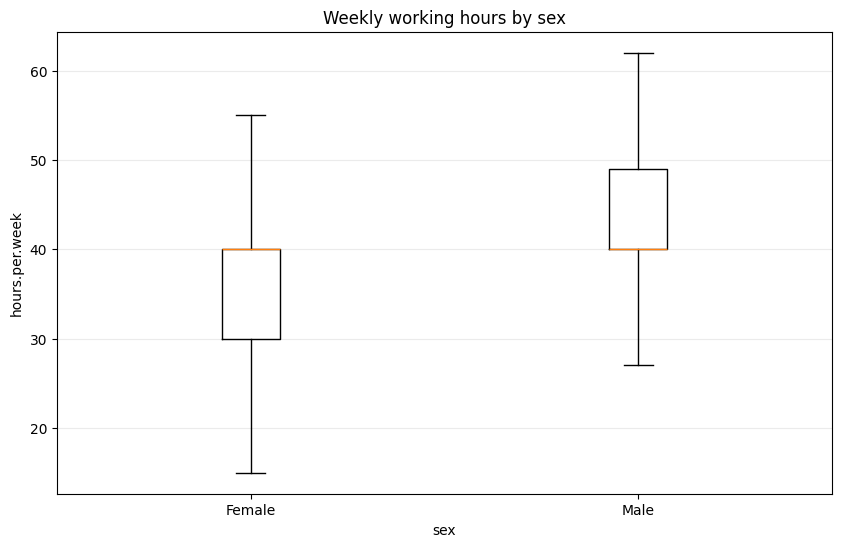

In [8]:
# sex vs hours.per.week

plot_df = train_prepared[["sex", "hours.per.week"]].copy()
sex_order = sorted(plot_df["sex"].dropna().unique().tolist())

summary_df = (
    plot_df.groupby("sex")["hours.per.week"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .reset_index()
)

display(summary_df)

fig, ax = plt.subplots(figsize=(10, 6))

hours_by_sex = [
    plot_df.loc[plot_df["sex"] == sex_value, "hours.per.week"].to_numpy()
    for sex_value in sex_order
]

ax.boxplot(hours_by_sex, tick_labels=sex_order, showfliers=False)
ax.set_title("Weekly working hours by sex")
ax.set_xlabel("sex")
ax.set_ylabel("hours.per.week")
ax.grid(axis="y", alpha=0.25)
plt.show()


income,sex,<=50K,>50K
0,Female,9583,1179
1,Male,15114,6660


income,sex,<=50K,>50K
0,Female,0.8904,0.1096
1,Male,0.6941,0.3059


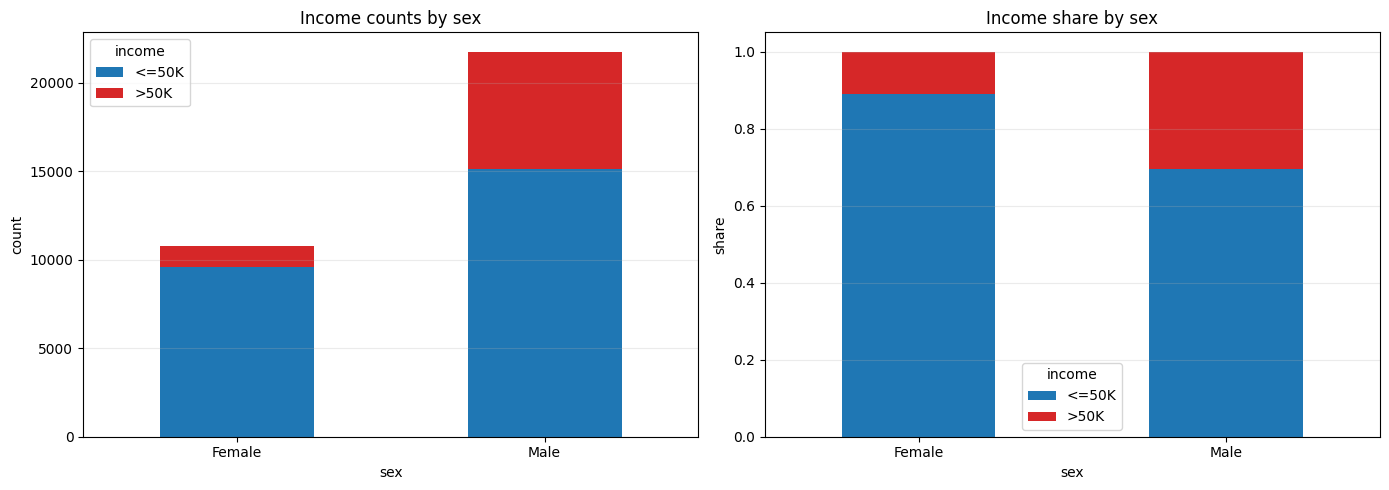

In [9]:
# sex vs income

plot_df = train_prepared[["sex", "income"]].copy()
sex_order = sorted(plot_df["sex"].dropna().unique().tolist())
income_order = ["<=50K", ">50K"]

count_df = (
    pd.crosstab(plot_df["sex"], plot_df["income"])
    .reindex(index=sex_order, columns=income_order)
    .fillna(0)
    .astype(int)
)

share_df = count_df.div(count_df.sum(axis=1), axis=0)

display(count_df.reset_index())
display(share_df.round(4).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

count_df.plot(kind="bar", stacked=True, ax=axes[0], color=["#1f77b4", "#d62728"])
axes[0].set_title("Income counts by sex")
axes[0].set_xlabel("sex")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.25)

share_df.plot(kind="bar", stacked=True, ax=axes[1], color=["#1f77b4", "#d62728"])
axes[1].set_title("Income share by sex")
axes[1].set_xlabel("sex")
axes[1].set_ylabel("share")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## Fair Comparison With kNN and SVM

The comparison below uses the kNN and SVM holdout metrics saved by the previous notebooks and the logistic regression holdout metrics from this notebook.

This is a fair local comparison because all three models use:

- the same prepared data;
- the same selected feature columns;
- the same stratified 80/20 development/holdout split;
- cross-validation only on the development set;
- final local evaluation only on the holdout set.

The competition test set is not used in this comparison because it has no local ground-truth labels.


,model,selection_hyperparameter,selected_value,accuracy,error_rate,balanced_accuracy,precision_positive,recall_positive,sensitivity,specificity,f1_positive,roc_auc
0,kNN,"k, weights, p","{""model__n_neighbors"": 61, ""model__p"": 1, ""model__weights"": ""uniform""}",0.84819,0.15181,0.77354,0.70803,0.62946,0.62946,0.91761,0.66644,0.90215
1,Linear SVM,C,"{""model__C"": 0.03}",0.84880,0.15120,0.75871,0.73360,0.58482,0.58482,0.93259,0.65082,0.89723
2,Logistic Regression,C,"{""model__C"": 0.3}",0.85049,0.14951,0.76396,0.73297,0.59694,0.59694,0.93097,0.65800,0.89756


,metric,best_model_on_holdout,best_value
0,accuracy,Logistic Regression,0.85049
1,balanced_accuracy,kNN,0.77354
2,precision_positive,Linear SVM,0.73360
3,recall_positive,kNN,0.62946
4,sensitivity,kNN,0.62946
5,specificity,Linear SVM,0.93259
6,f1_positive,kNN,0.66644
7,roc_auc,kNN,0.90215
8,error_rate,Logistic Regression,0.14951


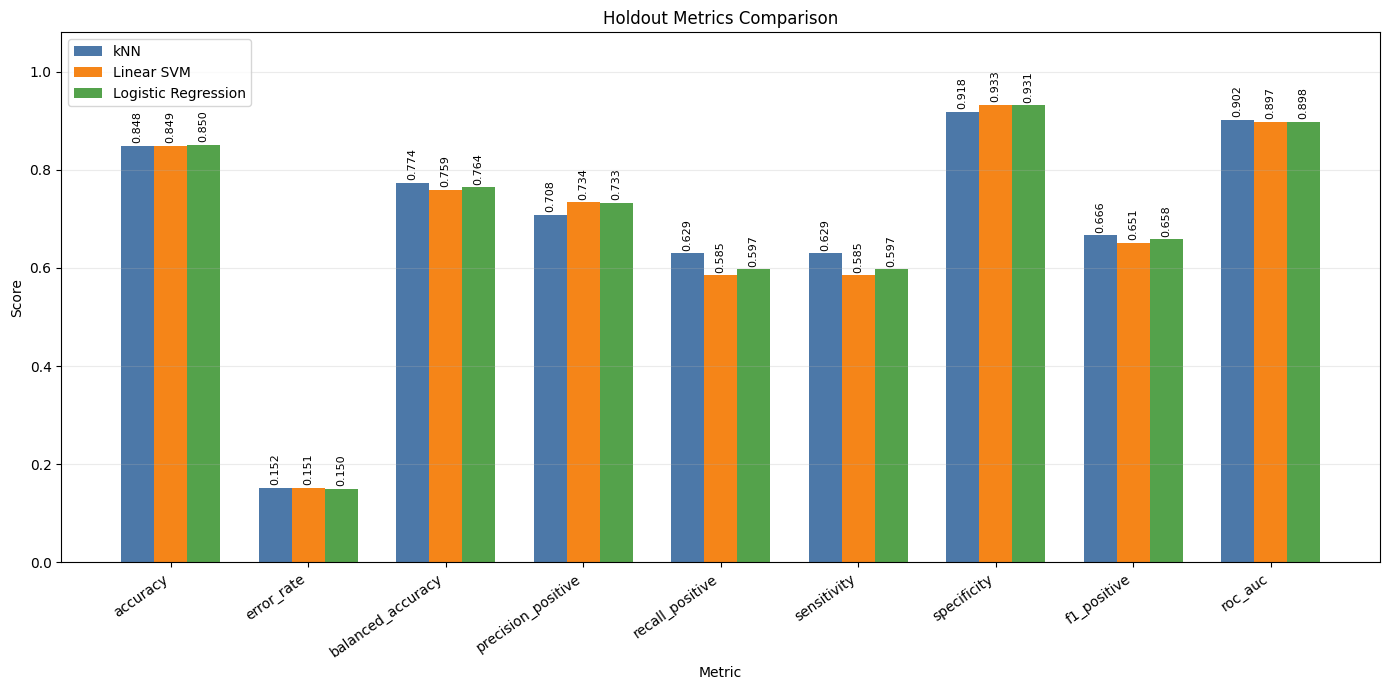

Comparison plot saved to `submissions/knn_vs_svm_vs_logreg_holdout_metrics.png`.

In [10]:
comparison_metric_order = [
    "accuracy",
    "error_rate",
    "balanced_accuracy",
    "precision_positive",
    "recall_positive",
    "sensitivity",
    "specificity",
    "f1_positive",
    "roc_auc",
]


def load_holdout_payload(filename):
    path = SUBMISSIONS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path.relative_to(PROJECT_ROOT)}. Run the corresponding notebook first.")
    return json.loads(path.read_text())


knn_payload = load_holdout_payload("knn_holdout_metrics.json")
svm_payload = load_holdout_payload("svm_holdout_metrics.json")

comparison_df = pd.DataFrame(
    [
        {
            "model": "kNN",
            "selection_hyperparameter": "k, weights, p",
            "selected_value": json.dumps(knn_payload["selected_params"], sort_keys=True),
            **{metric: float(knn_payload["holdout_metrics"].get(metric, np.nan)) for metric in comparison_metric_order},
        },
        {
            "model": "Linear SVM",
            "selection_hyperparameter": "C",
            "selected_value": json.dumps(svm_payload["selected_params"], sort_keys=True),
            **{metric: float(svm_payload["holdout_metrics"].get(metric, np.nan)) for metric in comparison_metric_order},
        },
        {
            "model": "Logistic Regression",
            "selection_hyperparameter": "C",
            "selected_value": json.dumps(selected_params, sort_keys=True),
            **{metric: float(holdout_metrics.get(metric, np.nan)) for metric in comparison_metric_order},
        },
    ],
    columns=["model", "selection_hyperparameter", "selected_value", *comparison_metric_order],
)

comparison_display_df = comparison_df.copy()
comparison_display_df[comparison_metric_order] = comparison_display_df[comparison_metric_order].round(5)
display(comparison_display_df)

best_by_metric_df = pd.DataFrame(
    [
        {
            "metric": metric,
            "best_model_on_holdout": comparison_df.loc[comparison_df[metric].idxmax(), "model"],
            "best_value": round(float(comparison_df[metric].max()), 5),
        }
        for metric in comparison_metric_order
        if metric != "error_rate"
    ]
    + [
        {
            "metric": "error_rate",
            "best_model_on_holdout": comparison_df.loc[comparison_df["error_rate"].idxmin(), "model"],
            "best_value": round(float(comparison_df["error_rate"].min()), 5),
        }
    ]
)

display(best_by_metric_df)

comparison_plot_path = SUBMISSIONS_DIR / "knn_vs_svm_vs_logreg_holdout_metrics.png"

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(comparison_metric_order))
bar_width = 0.24
offsets = np.linspace(-bar_width, bar_width, len(comparison_df))
colors = ["#4C78A8", "#F58518", "#54A24B"]

for offset, color, (_, row) in zip(offsets, colors, comparison_df.iterrows()):
    values = [row[metric] for metric in comparison_metric_order]
    bars = ax.bar(x + offset, values, width=bar_width, label=row["model"], color=color)
    ax.bar_label(
        bars,
        labels=[f"{value:.3f}" for value in values],
        padding=2,
        fontsize=8,
        rotation=90,
    )

ax.set_title("Holdout Metrics Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(comparison_metric_order, rotation=35, ha="right")
ax.set_ylim(0, 1.08)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(comparison_plot_path, dpi=180)
plt.show()

display(Markdown(f"Comparison plot saved to `{comparison_plot_path.relative_to(PROJECT_ROOT)}`."))


## Final Training and Submission Generation

After holdout evaluation, the selected logistic regression pipeline is fit again using **the full labeled training set**.

This is done because, once `C` has been selected and evaluated, we want to use all available labeled examples to generate predictions for the competition test set.

Important notes:

- The final test set does not include `income`, so local accuracy cannot be computed on it.
- The reliable metrics in this notebook come from the holdout split.
- `logreg_submission.csv` contains only the final predictions for submission.

Saved artifacts:

- `submissions/logreg_grid_search_results.csv`: full `GridSearchCV` result table.
- `submissions/logreg_best_params.json`: selected hyperparameter and fold accuracies.
- `submissions/logreg_holdout_metrics.json`: holdout metrics and confusion matrix.
- `submissions/logreg_submission.csv`: final predictions for the test set.
- `submissions/knn_vs_svm_vs_logreg_holdout_comparison.csv`: consolidated holdout comparison table.
- `submissions/knn_vs_svm_vs_logreg_holdout_metrics.png`: grouped bar chart comparing the three holdout metric profiles.


In [11]:
final_pipeline = clone(base_pipeline).set_params(**selected_params)
final_pipeline.fit(X_train_full, y_binary)

test_pred_proba = final_pipeline.predict_proba(X_test_final)[:, 1]
test_pred_binary = (test_pred_proba >= DECISION_THRESHOLD).astype(int)
test_pred_labels = np.where(test_pred_binary == 1, POSITIVE_LABEL, NEGATIVE_LABEL)

submission_df = pd.DataFrame(
    {
        ID_COL: test_prepared[ID_COL].values,
        TARGET_COL: test_pred_labels,
    }
)

assert submission_df.columns.tolist() == [ID_COL, TARGET_COL], "Submission columns must be Id and income."
assert len(submission_df) == len(test_prepared), "Submission row count must match test_prepared.csv."
assert set(submission_df[TARGET_COL].unique()).issubset({NEGATIVE_LABEL, POSITIVE_LABEL}), "Submission labels must be <=50K or >50K."
assert comparison_df["model"].tolist() == ["kNN", "Linear SVM", "Logistic Regression"], "Comparison table must contain kNN, SVM, and logistic regression in order."

submission_path = SUBMISSIONS_DIR / "logreg_submission.csv"
metrics_path = SUBMISSIONS_DIR / "logreg_holdout_metrics.json"
best_params_path = SUBMISSIONS_DIR / "logreg_best_params.json"
grid_results_path = SUBMISSIONS_DIR / "logreg_grid_search_results.csv"
comparison_path = SUBMISSIONS_DIR / "knn_vs_svm_vs_logreg_holdout_comparison.csv"

holdout_metrics_payload = {
    "selected_params": selected_params,
    "best_mean_cv_accuracy": float(selected_row["mean_cv_accuracy"]),
    "holdout_metrics": holdout_metrics,
    "holdout_confusion_matrix": confusion_df.to_dict(),
    "holdout_confusion_terms": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    },
    "evaluation_protocol": {
        "development_split": "80% of labeled train_prepared.csv, stratified, used for CV/model selection",
        "holdout_split": "20% of labeled train_prepared.csv, stratified, used only for final local evaluation",
        "competition_test": "test_prepared.csv, no local labels, used only for final submission predictions",
        "cv": f"{N_FOLDS}-fold StratifiedKFold with shuffle=True and random_state=42",
        "selection_metric": "accuracy",
    },
}

best_params_payload = {
    "grid_search_best_params": grid_search.best_params_,
    "tie_break_selected_params": selected_params,
    "tie_break_changed_selection": bool(grid_search.best_params_ != selected_params),
    "tie_break_rule": TIE_BREAK_RULE,
    "selected_mean_cv_accuracy": float(selected_row["mean_cv_accuracy"]),
    "selected_mean_cv_accuracy_rounded": float(selected_row["mean_cv_accuracy_rounded"]),
    "selected_std_cv_accuracy": float(selected_row["std_cv_accuracy"]),
    "selected_fold_accuracies": selected_fold_accuracies,
    "selected_fold_accuracy_by_fold": selected_fold_accuracy_records,
    "tested_C_values": C_VALUES,
}

cv_results_output_df = cv_results_df.sort_values("logreg_C").reset_index(drop=True).copy()
cv_results_output_df["rank"] = cv_results_output_df["grid_rank"]
cv_results_output_df["selected"] = cv_results_output_df["logreg_C"] == selected_params["model__C"]

submission_df.to_csv(submission_path, index=False)
cv_results_output_df.to_csv(grid_results_path, index=False)
comparison_df.to_csv(comparison_path, index=False)
metrics_path.write_text(json.dumps(holdout_metrics_payload, indent=2))
best_params_path.write_text(json.dumps(best_params_payload, indent=2))

saved_artifacts_df = pd.DataFrame(
    [
        {"artifact": "grid_search_results", "path": str(grid_results_path.relative_to(PROJECT_ROOT))},
        {"artifact": "best_params", "path": str(best_params_path.relative_to(PROJECT_ROOT))},
        {"artifact": "holdout_metrics", "path": str(metrics_path.relative_to(PROJECT_ROOT))},
        {"artifact": "submission", "path": str(submission_path.relative_to(PROJECT_ROOT))},
        {"artifact": "holdout_comparison", "path": str(comparison_path.relative_to(PROJECT_ROOT))},
        {"artifact": "holdout_comparison_plot", "path": str(comparison_plot_path.relative_to(PROJECT_ROOT))},
    ]
)

display(saved_artifacts_df)
display(submission_df.head())
display(Markdown("### Final holdout comparison table"))
display(comparison_display_df)
display(Markdown(f"Submission saved to `{submission_path.relative_to(PROJECT_ROOT)}`."))


,artifact,path
0,grid_search_results,submissions/logreg_grid_search_results.csv
1,best_params,submissions/logreg_best_params.json
2,holdout_metrics,submissions/logreg_holdout_metrics.json
3,submission,submissions/logreg_submission.csv
4,holdout_comparison,submissions/knn_vs_svm_vs_logreg_holdout_comparison.csv
5,holdout_comparison_plot,submissions/knn_vs_svm_vs_logreg_holdout_metrics.png


,Id,income
0,0,<=50K
1,1,>50K
2,2,<=50K
3,3,<=50K
4,4,>50K


### Final holdout comparison table

,model,selection_hyperparameter,selected_value,accuracy,error_rate,balanced_accuracy,precision_positive,recall_positive,sensitivity,specificity,f1_positive,roc_auc
0,kNN,"k, weights, p","{""model__n_neighbors"": 61, ""model__p"": 1, ""model__weights"": ""uniform""}",0.84819,0.15181,0.77354,0.70803,0.62946,0.62946,0.91761,0.66644,0.90215
1,Linear SVM,C,"{""model__C"": 0.03}",0.84880,0.15120,0.75871,0.73360,0.58482,0.58482,0.93259,0.65082,0.89723
2,Logistic Regression,C,"{""model__C"": 0.3}",0.85049,0.14951,0.76396,0.73297,0.59694,0.59694,0.93097,0.65800,0.89756


Submission saved to `submissions/logreg_submission.csv`.